In [3]:
"""
FIND-S Algorithm
=================
Learns the maximally specific hypothesis consistent with all positive
training examples. Negative examples are ignored.

Hypothesis notation:
    '?'  -> any value is acceptable
    '0'  -> no value is acceptable yet
    'x'  -> a specific required value
"""


def find_s(training_data, target_col="BuyLaptop", positive_label="Yes"):
    """
    training_data: list of dictionaries, each representing one training example.
    target_col: name of the target/output column.
    positive_label: value representing a positive example.

    Returns:
        Final maximally specific hypothesis.
    """

    # Get all attributes except target column
    attributes = [
        a for a in training_data[0].keys()
        if a != target_col
    ]

    # Step 1: Initialize hypothesis to the most specific hypothesis
    hypothesis = {attr: "0" for attr in attributes}

    print(f"h0 (initial) : {hypothesis}\n")

    # Step 2 & 3: Process each training example
    for i, example in enumerate(training_data, start=1):

        label = example[target_col]

        # Ignore negative examples
        if label != positive_label:
            print(f"Example {i} ({label}): negative -> ignored")
            continue

        # Process positive example
        for attr in attributes:

            if hypothesis[attr] == "0":
                # First positive example
                hypothesis[attr] = example[attr]

            elif hypothesis[attr] != example[attr]:
                # Attribute value differs, so generalize
                hypothesis[attr] = "?"

            # If values are the same, keep the existing value

        print(
            f"Example {i} ({label}): positive -> h{i} = {hypothesis}"
        )

    print(f"\nFinal hypothesis: {hypothesis}")

    return hypothesis


if __name__ == "__main__":

    # New Laptop Purchase Dataset
    training_data = [

        {
            "Brand": "Dell",
            "RAM": "16GB",
            "Storage": "512GB",
            "Processor": "i5",
            "Price": "Medium",
            "BuyLaptop": "Yes"
        },

        {
            "Brand": "HP",
            "RAM": "16GB",
            "Storage": "512GB",
            "Processor": "i5",
            "Price": "Medium",
            "BuyLaptop": "Yes"
        },

        {
            "Brand": "Lenovo",
            "RAM": "8GB",
            "Storage": "512GB",
            "Processor": "i5",
            "Price": "Low",
            "BuyLaptop": "No"
        },

        {
            "Brand": "Dell",
            "RAM": "16GB",
            "Storage": "1TB",
            "Processor": "i7",
            "Price": "High",
            "BuyLaptop": "Yes"
        },

        {
            "Brand": "Acer",
            "RAM": "8GB",
            "Storage": "256GB",
            "Processor": "i3",
            "Price": "Low",
            "BuyLaptop": "No"
        },

        {
            "Brand": "HP",
            "RAM": "16GB",
            "Storage": "1TB",
            "Processor": "i7",
            "Price": "High",
            "BuyLaptop": "Yes"
        },
    ]

    # Run FIND-S algorithm
    final_hypothesis = find_s(training_data)

h0 (initial) : {'Brand': '0', 'RAM': '0', 'Storage': '0', 'Processor': '0', 'Price': '0'}

Example 1 (Yes): positive -> h1 = {'Brand': 'Dell', 'RAM': '16GB', 'Storage': '512GB', 'Processor': 'i5', 'Price': 'Medium'}
Example 2 (Yes): positive -> h2 = {'Brand': '?', 'RAM': '16GB', 'Storage': '512GB', 'Processor': 'i5', 'Price': 'Medium'}
Example 3 (No): negative -> ignored
Example 4 (Yes): positive -> h4 = {'Brand': '?', 'RAM': '16GB', 'Storage': '?', 'Processor': '?', 'Price': '?'}
Example 5 (No): negative -> ignored
Example 6 (Yes): positive -> h6 = {'Brand': '?', 'RAM': '16GB', 'Storage': '?', 'Processor': '?', 'Price': '?'}

Final hypothesis: {'Brand': '?', 'RAM': '16GB', 'Storage': '?', 'Processor': '?', 'Price': '?'}



Step-by-step hypothesis:
  h0: {'Brand': '0', 'RAM': '0', 'Storage': '0', 'Processor': '0', 'Price': '0'}
  h1: {'Brand': 'Dell', 'RAM': '16GB', 'Storage': '512GB', 'Processor': 'i5', 'Price': 'Medium'}
  h2: {'Brand': '?', 'RAM': '16GB', 'Storage': '512GB', 'Processor': 'i5', 'Price': 'Medium'}
  Ex3 (neg): {'Brand': '?', 'RAM': '16GB', 'Storage': '512GB', 'Processor': 'i5', 'Price': 'Medium'}
  h4: {'Brand': '?', 'RAM': '16GB', 'Storage': '?', 'Processor': '?', 'Price': '?'}
  Ex5 (neg): {'Brand': '?', 'RAM': '16GB', 'Storage': '?', 'Processor': '?', 'Price': '?'}
  h6: {'Brand': '?', 'RAM': '16GB', 'Storage': '?', 'Processor': '?', 'Price': '?'}

Final hypothesis:
{'Brand': '?', 'RAM': '16GB', 'Storage': '?', 'Processor': '?', 'Price': '?'}

Generating graphs...


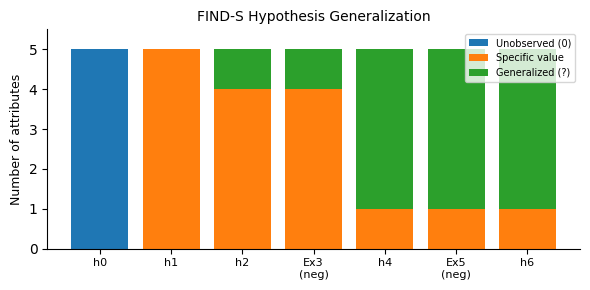

Saved: laptop_specificity_trend.png


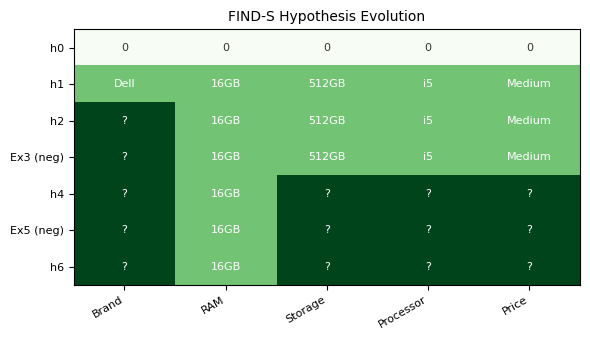

Saved: laptop_hypothesis_heatmap.png

All graphs generated successfully!


In [5]:
"""
FIND-S Algorithm with Visual Analysis
======================================

Runs FIND-S on a Laptop Purchase dataset, keeps a full history of the
hypothesis after every training example, then plots:

1. Specificity Trend -> Small stacked bar chart
2. Hypothesis Heatmap -> Small attribute-by-step grid

Hypothesis notation:
    '0' -> no value accepted yet
    '?' -> any value accepted
    'x' -> a specific required value
"""

import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------
# 1. FIND-S CORE ALGORITHM
# ----------------------------------------------------------------------

def find_s_with_history(
    training_data,
    target_col="BuyLaptop",
    positive_label="Yes"
):

    # Get attribute names
    attributes = [
        a for a in training_data[0].keys()
        if a != target_col
    ]

    # Initial hypothesis
    hypothesis = {
        attr: "0"
        for attr in attributes
    }

    # Store initial hypothesis
    history = [
        ("h0", dict(hypothesis), None)
    ]

    # Process each training example
    for i, example in enumerate(training_data, start=1):

        label = example[target_col]

        # --------------------------------------------------------------
        # Ignore negative examples
        # --------------------------------------------------------------
        if label != positive_label:

            history.append(
                (
                    f"Ex{i}\n(neg)",
                    dict(hypothesis),
                    False
                )
            )

            continue

        # --------------------------------------------------------------
        # Process positive example
        # --------------------------------------------------------------
        for attr in attributes:

            # First positive value
            if hypothesis[attr] == "0":

                hypothesis[attr] = example[attr]

            # Different value -> generalize
            elif hypothesis[attr] != example[attr]:

                hypothesis[attr] = "?"

        # Store hypothesis after positive example
        history.append(
            (
                f"h{i}",
                dict(hypothesis),
                True
            )
        )

    return hypothesis, history, attributes


# ----------------------------------------------------------------------
# 2. PLOT: SPECIFICITY TREND
# ----------------------------------------------------------------------

def plot_specificity_trend(
    history,
    attributes,
    save_as="laptop_specificity_trend.png"
):

    steps = [
        h[0]
        for h in history
    ]

    unobserved = []
    specific = []
    general = []

    # Count the three types of attributes
    for _, hyp, _ in history:

        # Generalized attributes
        g = sum(
            1
            for v in hyp.values()
            if v == "?"
        )

        # Unobserved attributes
        u = sum(
            1
            for v in hyp.values()
            if v == "0"
        )

        # Specific attributes
        s = len(attributes) - g - u

        unobserved.append(u)
        specific.append(s)
        general.append(g)

    x = np.arange(
        len(steps)
    )

    # --------------------------------------------------------------
    # SMALL GRAPH
    # --------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(6, 3)
    )

    # Unobserved
    ax.bar(
        x,
        unobserved,
        label="Unobserved (0)"
    )

    # Specific
    ax.bar(
        x,
        specific,
        bottom=unobserved,
        label="Specific value"
    )

    # Bottom position for generalized values
    bottom2 = (
        np.array(unobserved)
        + np.array(specific)
    )

    # Generalized
    ax.bar(
        x,
        general,
        bottom=bottom2,
        label="Generalized (?)"
    )

    # X-axis
    ax.set_xticks(x)

    ax.set_xticklabels(
        steps,
        fontsize=8
    )

    # Y-axis
    ax.set_ylabel(
        "Number of attributes",
        fontsize=9
    )

    # Title
    ax.set_title(
        "FIND-S Hypothesis Generalization",
        fontsize=10
    )

    # Y-axis limit
    ax.set_ylim(
        0,
        len(attributes) + 0.5
    )

    # Legend
    ax.legend(
        loc="upper right",
        fontsize=7
    )

    # Remove top and right borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Adjust layout
    plt.tight_layout()

    # Save graph
    plt.savefig(
        save_as,
        dpi=150,
        bbox_inches="tight"
    )

    # Display graph
    plt.show()

    print(
        f"Saved: {save_as}"
    )


# ----------------------------------------------------------------------
# 3. PLOT: HYPOTHESIS EVOLUTION HEATMAP
# ----------------------------------------------------------------------

def plot_hypothesis_heatmap(
    history,
    attributes,
    save_as="laptop_hypothesis_heatmap.png"
):

    # Encoding:
    #
    # 0 = Unobserved
    # 1 = Specific
    # 2 = Generalized

    grid = []

    for _, hyp, _ in history:

        row = [

            0
            if hyp[a] == "0"

            else (
                2
                if hyp[a] == "?"
                else 1
            )

            for a in attributes
        ]

        grid.append(row)

    grid = np.array(
        grid
    )

    # --------------------------------------------------------------
    # SMALL GRAPH
    # --------------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(6, 3.5)
    )

    # Create heatmap
    im = ax.imshow(
        grid,
        cmap="Greens",
        aspect="auto",
        vmin=0,
        vmax=2
    )

    # --------------------------------------------------------------
    # X-AXIS
    # --------------------------------------------------------------

    ax.set_xticks(
        range(len(attributes))
    )

    ax.set_xticklabels(
        attributes,
        rotation=30,
        ha="right",
        fontsize=8
    )

    # --------------------------------------------------------------
    # Y-AXIS
    # --------------------------------------------------------------

    ax.set_yticks(
        range(len(history))
    )

    ax.set_yticklabels(
        [
            h[0].replace(
                "\n",
                " "
            )
            for h in history
        ],
        fontsize=8
    )

    # --------------------------------------------------------------
    # DISPLAY ACTUAL HYPOTHESIS VALUES
    # --------------------------------------------------------------

    for i, (_, hyp, _) in enumerate(history):

        for j, attr in enumerate(attributes):

            # Text color
            text_color = (
                "white"
                if grid[i, j] >= 1
                else "#333333"
            )

            ax.text(
                j,
                i,
                hyp[attr],
                ha="center",
                va="center",
                fontsize=8,
                color=text_color
            )

    # Title
    ax.set_title(
        "FIND-S Hypothesis Evolution",
        fontsize=10
    )

    # Adjust layout
    plt.tight_layout()

    # Save graph
    plt.savefig(
        save_as,
        dpi=150,
        bbox_inches="tight"
    )

    # Display graph
    plt.show()

    print(
        f"Saved: {save_as}"
    )


# ----------------------------------------------------------------------
# 4. MAIN PROGRAM
# ----------------------------------------------------------------------

if __name__ == "__main__":

    # ==============================================================
    # LAPTOP PURCHASE DATASET
    # ==============================================================

    training_data = [

        {
            "Brand": "Dell",
            "RAM": "16GB",
            "Storage": "512GB",
            "Processor": "i5",
            "Price": "Medium",
            "BuyLaptop": "Yes"
        },

        {
            "Brand": "HP",
            "RAM": "16GB",
            "Storage": "512GB",
            "Processor": "i5",
            "Price": "Medium",
            "BuyLaptop": "Yes"
        },

        {
            "Brand": "Lenovo",
            "RAM": "8GB",
            "Storage": "512GB",
            "Processor": "i5",
            "Price": "Low",
            "BuyLaptop": "No"
        },

        {
            "Brand": "Dell",
            "RAM": "16GB",
            "Storage": "1TB",
            "Processor": "i7",
            "Price": "High",
            "BuyLaptop": "Yes"
        },

        {
            "Brand": "Acer",
            "RAM": "8GB",
            "Storage": "256GB",
            "Processor": "i3",
            "Price": "Low",
            "BuyLaptop": "No"
        },

        {
            "Brand": "HP",
            "RAM": "16GB",
            "Storage": "1TB",
            "Processor": "i7",
            "Price": "High",
            "BuyLaptop": "Yes"
        }
    ]


    # ==============================================================
    # RUN FIND-S
    # ==============================================================

    final_hypothesis, history, attributes = (
        find_s_with_history(
            training_data
        )
    )


    # ==============================================================
    # DISPLAY STEP-BY-STEP HYPOTHESIS
    # ==============================================================

    print(
        "\nStep-by-step hypothesis:"
    )

    for label, hyp, _ in history:

        print(
            f"  {label.replace(chr(10), ' ')}: {hyp}"
        )


    # ==============================================================
    # DISPLAY FINAL HYPOTHESIS
    # ==============================================================

    print(
        "\nFinal hypothesis:"
    )

    print(
        final_hypothesis
    )


    # ==============================================================
    # GENERATE SMALL GRAPHS
    # ==============================================================

    print(
        "\nGenerating graphs..."
    )

    # Graph 1
    plot_specificity_trend(
        history,
        attributes,
        save_as="laptop_specificity_trend.png"
    )

    # Graph 2
    plot_hypothesis_heatmap(
        history,
        attributes,
        save_as="laptop_hypothesis_heatmap.png"
    )

    print(
        "\nAll graphs generated successfully!"
    )